# W03A - Metropolis Monte Carlo Optimization

In [1]:
import numpy as np
import matplotlib.pyplot as plt

### Task 1 - plotting

Text(0.02, 0.5, 'Potential Energy V(x)')

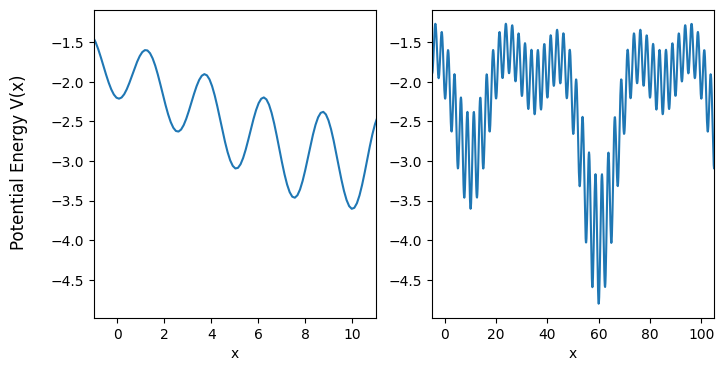

In [2]:
def V(x):
    return (-1 -np.exp (-((x+15) /10) **2) \
            -2*np.exp (-((x -10) /10) **2) + \
            -np.exp (-((x -35) /10) **2) \
            -3*np.exp (-((x -60) /10) **2) \
            -np.exp (-((x -85) /10) **2)\
            -2*np.exp (-((x -110) /10) **2) \
            ) * \
            (1+1/5* np.cos (2* np.pi /2.5*x))

xs = np.linspace(-5,105,1000)
fig, axes = plt.subplots(1,2,figsize=(8,4))
for ax in axes:
    ax.plot(xs, V(xs))
    ax.set_xlabel('x')
axes[0].set_xlim(-1,11)
axes[1].set_xlim(-5,105)
fig.supylabel('Potential Energy V(x)')

### Task 2
Use the Metropolis Monte Carlo method to create a Markov chain trajectory at two different
temperatures

In [3]:
class System():

    def __init__(self, n_steps = 1, kT=1/3, xmin=-1, xmax=11, x=0, delta=0.1):
        self.kT = kT
        self.xmin = xmin
        self.xmax = xmax
        self.n_steps = n_steps

        self.xopt = 0
        self.yopt = 0

        self.x = x
        self.delta = delta

        self.energy = self.get_V(self.x)
        self.states = self.run_Metropolis_Monte_Carlo()
        
        self.xspace = np.linspace(self.xmin, self.xmax, 100)
        self.energies = self.get_V(self.xspace)

    def get_V(self, x):
        return V(x)

    def proposed_x(self):
        p_x = self.x + np.random.normal(0, self.delta)
        if p_x < self.xmin:
            p_x = self.xmin
        if p_x > self.xmax:
            p_x = self.xmax
        return p_x
    
    def step(self):
        proposed_x = self.proposed_x()
        proposed_energy = self.get_V(proposed_x)
        delta_E = proposed_energy - self.energy
        acceptance_probability = min(1, np.exp(-delta_E / self.kT))  # using P(x')/P(x) = exp(-E'/kT)/exp(E/kT) = exp(-delta_E/kT)
        # a clever way to choose randomly given a probability
        # if acceptance_probability=0.4, it is chosen 40% of times.
        if np.random.rand() < acceptance_probability:
            self.x = proposed_x
            self.energy = proposed_energy
    
    def run_Metropolis_Monte_Carlo(self):
        states = []
        states.append((self.x, self.get_V(self.x)))
        for _ in range(self.n_steps):
            self.step()
            energy = self.get_V(self.x)
            states.append((self.x, energy))
            if energy < self.yopt:
                self.xopt = self.x
                self.yopt = energy
        return states

    def plot(self, axes, title):
        x_points, y_points = zip(*self.states)

        axes[0].plot(x_points,range(len(x_points)),'-',color='k')
        for i, x in enumerate(x_points):
            axes[0].plot(x,i, '.',ms=12)
        
        axes[1].plot(xs, V(xs), color='k')
        for x, y in zip(x_points, y_points):
            axes[1].plot(x,y,'.', ms=12)

        for ax in axes:
            ax.set_xlim(-1,11)
        axes[1].set_ylim(-4,-1)

        axes[0].set_title(title)
        axes[0].set_ylabel('Monte Carlo time')
        axes[1].set_ylabel('Potential Energy V(x)')
        axes[1].set_xlabel('x')

    def big_plot(self, ax):
        x_points, y_points = zip(*self.states)
        ax.plot(xs, V(xs))
        ax.plot(x_points, y_points, '.-', color='k', ms=6, label=f'kT={self.kT}\n'+r'$\sigma=$'+f'{self.delta}')
        print(self.xopt, self.yopt)
        ax.legend(loc='lower right')
        ax.scatter(self.xopt, self.yopt, color='red', s=100)
        # ax.plot(x_points[::self.n_steps//20], y_points[::self.n_steps//20], '.-', color='k', ms=6)


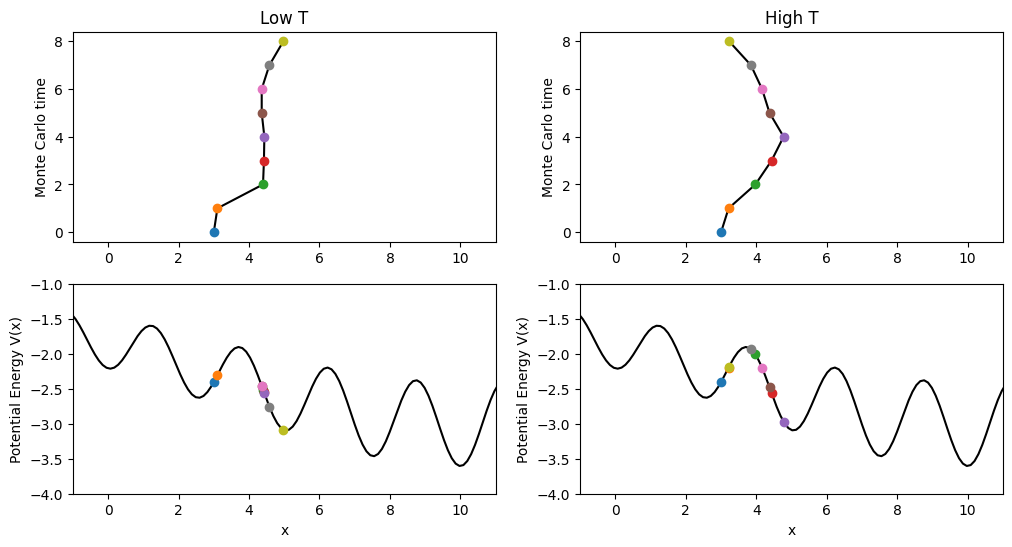

In [4]:
s_lowT = System(n_steps=8, kT=0.2, x=3, delta=0.5)
s_highT = System(n_steps=8, kT=2, x=3, delta=0.5)

fig, axes = plt.subplots(2,2,figsize=(12,6))
s_lowT.plot((axes[0,0], axes[1,0]), 'Low T')
s_highT.plot((axes[0,1], axes[1,1]), 'High T')

It appears that with this parameter for delta=0.5, the higher temperature is capable to "jump" the peaks and escape the potential.

### Task 3+4
Make some number of walkers and observe their ability to identify the global minimum

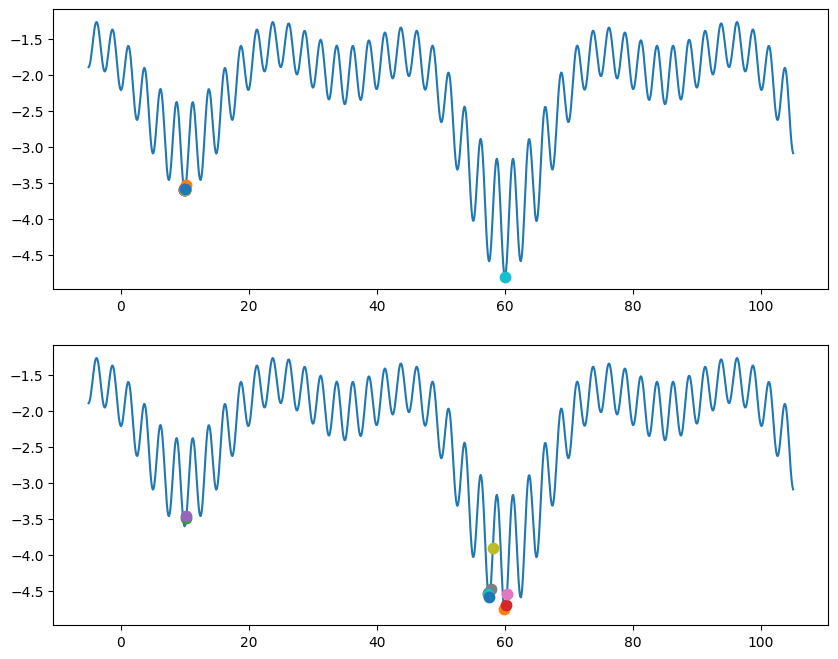

In [5]:
fig, axes = plt.subplots(2,1,figsize=(10,8))
for ax in axes:
    ax.plot(xs, V(xs))
for _ in range(10):
    s_lowT = System(n_steps=100, kT=0.2, x=3, xmin=-5, xmax=105, delta=10)
    s_highT = System(n_steps=100, kT=2, x=3, xmin=-5, xmax=105, delta=10)
    axes[0].plot(s_lowT.xopt, s_lowT.yopt, '.', ms=15)
    axes[1].plot(s_highT.xopt, s_highT.yopt, '.', ms=15)


It appears that more walkers find their way to the global minimum when the temperature increases.

9.772684228123909 -3.508047303370827
9.828476597197993 -3.548990332228219
59.78909245626653 -4.693203880238897
60.07300747204567 -4.791002252325203


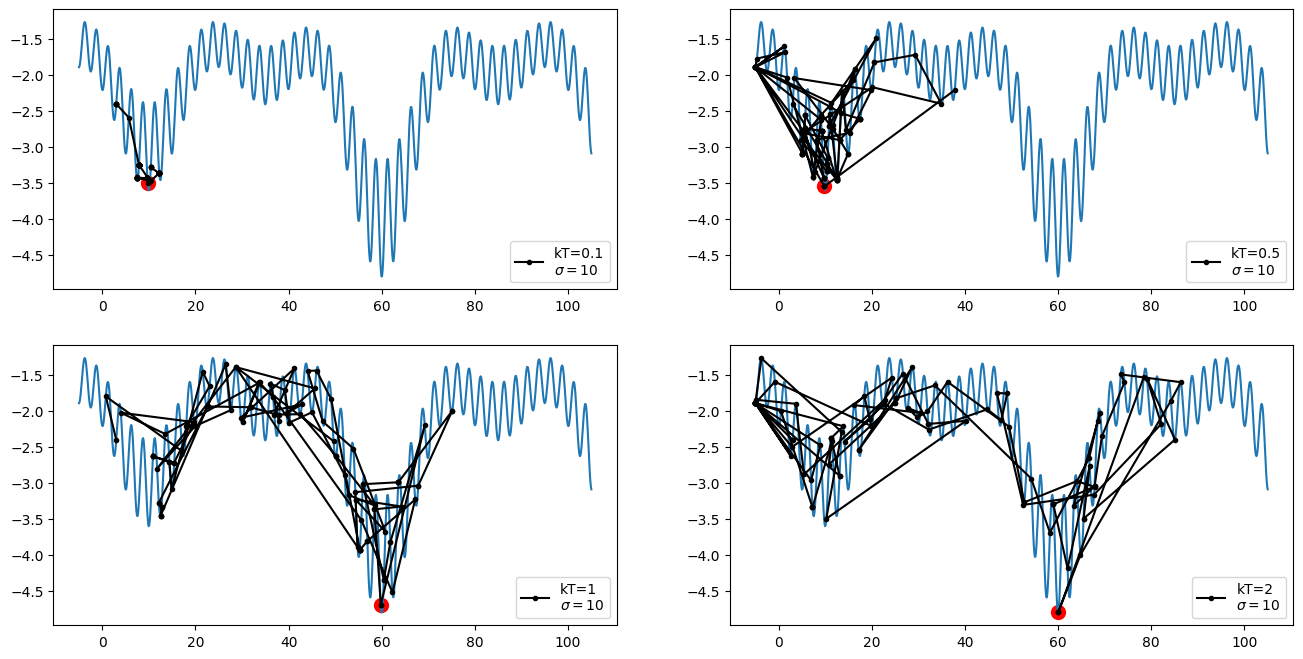

In [6]:
fig, axes = plt.subplots(2,2,figsize=(16,8))
for kT, ax in zip([0.1, 0.5, 1, 2], axes.flatten()):
    s_highT = System(n_steps=100, kT=kT, x=3, xmin=-5, xmax=105, delta=10)
    s_highT.big_plot(ax)

7.508704425418764 -3.4636254046420754
10.10454942385542 -3.583757399616155
9.959368700333327 -3.601464675980752
59.71590448503471 -4.606293206183223


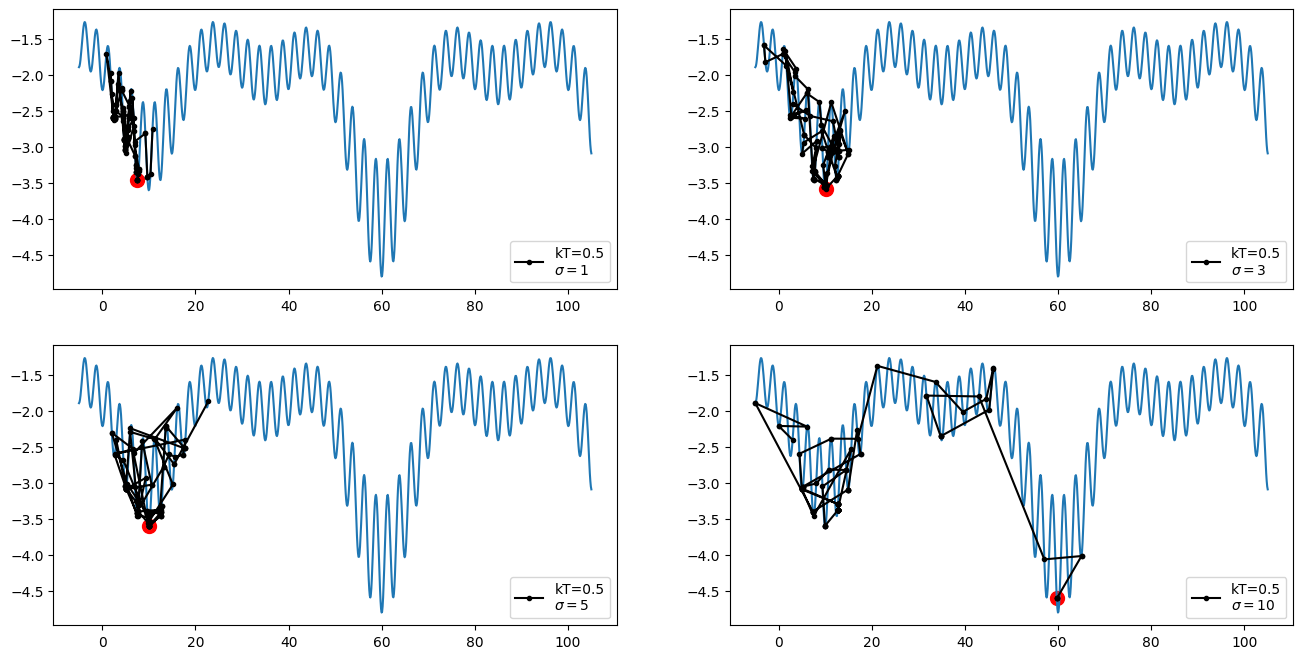

In [7]:
fig, axes = plt.subplots(2,2,figsize=(16,8))
for sigma, ax in zip([1, 3, 5, 10], axes.flatten()):
    s_highT = System(n_steps=100, kT=0.5, x=3, xmin=-5, xmax=105, delta=sigma)
    s_highT.big_plot(ax)

# W03B - The Morse potential

### Task 1
Plot the potential

In [8]:
class System():
    def __init__(self, r0=1, eps=3/2, a=2):
        self.r0 = r0
        self.eps = eps
        self.a = a

        self.rs = np.linspace(0.1, 4, 100)
        self.morse_pot = self.get_pot(self.rs)

    def get_pot(self, r):
        return self.eps * ((1 - np.exp(-self.a*(r-self.r0)))**2 - 1)

    def plot_pot(self, ax):
        ax.plot(self.rs, self.morse_pot)
        ax.set_ylim(-2, 5)
        ax.grid()
    

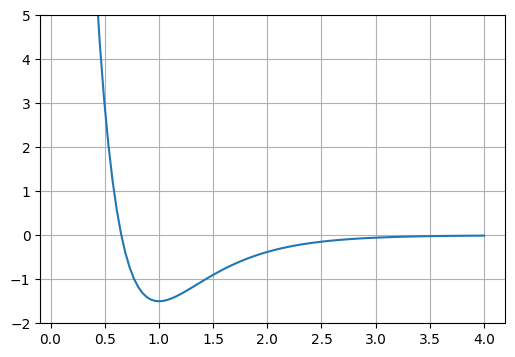

In [9]:
s = System()
fig, ax = plt.subplots(1,1,figsize=(6,4))
s.plot_pot(ax)

### Task 2

Get potential energy using a calculator

In [10]:
from scipy.spatial.distance import pdist
class Calculator ():
    def potential_energy (self , pos):
        return np.sum(self._V(pdist(pos)))

class Morse(Calculator):

    a = 2
    eps = 3/2
    r0 = 1

    def _V(self, r):
        return self.eps * ((1 - np.exp(-self.a*(r-self.r0)))**2 - 1)

morse = Morse()

pos = np.array ([[0 , 0], [3/2 , 0], [0, 1]])

print(f'{morse.potential_energy(pos):.2f}')

-2.94


### Task 3
Implement the calculator to a cluster class

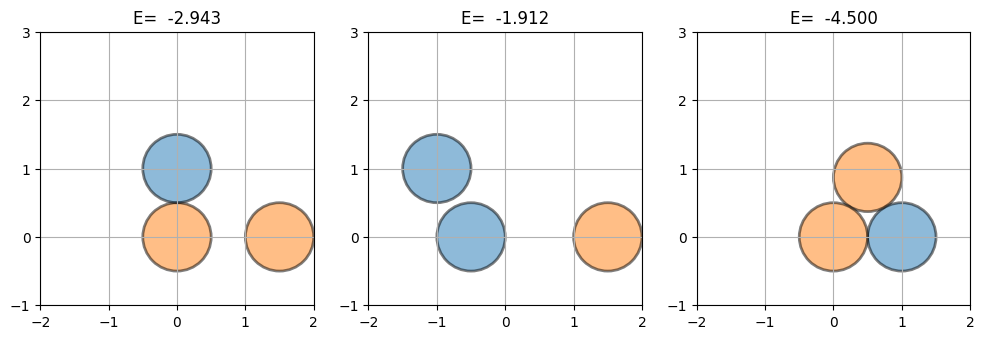

In [11]:
import matplotlib .pyplot as plt
from week03 import nice_plot, AtomicClusterBase


class AtomicCluster(AtomicClusterBase):
    @property
    def potential_energy(self):
        return self.calc.potential_energy(self.pos)
    # combine self.calc and self.pos to return the potential energy of the cluster

fig , axes = plt.subplots (1,3, figsize =(12 ,4))

cluster0 = AtomicCluster(morse, pos = [[0 , 0], [3/2 , 0], [0, 1]], static = [True, True, False])
cluster1 = AtomicCluster(morse, pos = [[-1/2 , 0], [3/2 , 0], [-1, 1]], static = [False, True, False])
cluster2 = AtomicCluster(morse, pos = [[1 , 0], [1/2 , 0.87], [0, 0]], static = [False, True, True])
for ax , cluster in zip(axes, [cluster0, cluster1, cluster2]):  
    cluster.draw(ax)
    nice_plot(ax)

### Task 4
Make a contour plot

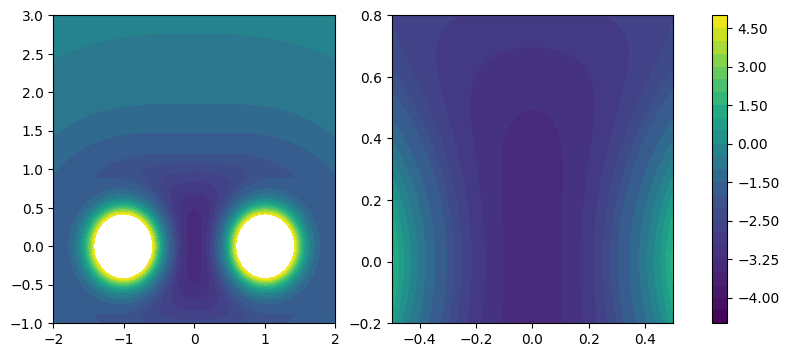

In [12]:
p0 = [0,0]
p1 = [-1,0]
p2 = [1,0]
pos0 = np.array([p0, p1, p2])
cluster = AtomicCluster(morse, pos = pos0, static = [True, False, False])
fig, axes = plt.subplots(1,2, figsize=(10,4))

xs = np.linspace(-2, 2, 100)
ys = np.linspace(-1, 3, 100)

xd, yd = np.meshgrid(xs,ys)
zd = np.zeros(xd.shape)

for i, j in np.ndindex(xd.shape): #run through xd like a matrix:
    cluster.pos = np.array([[xd[i, j],yd[i, j]], p1, p2])
    zd[i,j] = cluster.potential_energy    # get the energy into the contour plot for position i, j

levels = list(np.arange(-4.5, -2, step=0.25)) + list(np.arange(-2, 5.001, 0.5))

for ax in axes:
    cf = ax.contourf(xd, yd, zd, levels=levels)

axes[1].set_ylim(-0.2,0.8)
axes[1].set_xlim(-0.5,0.5)

fig.colorbar(cf, ax=axes)

### Task 5



26


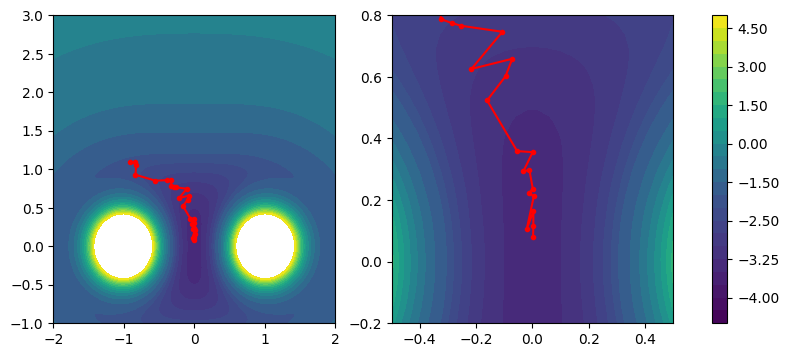

In [13]:
class AtomicClusterWithRattleOfFirstAtom(AtomicCluster):
    def rattle_first_atom(self, A=0.1):
        index = 0
        delta_r = [np.random.normal(0, A), np.random.normal(0,A)]
        self.pos[index, :] += delta_r

cluster = AtomicClusterWithRattleOfFirstAtom(morse, pos=np.array([[-1, 1.2],[-1,0],[1,0]]),  static = [True, False, False])

def monte_carlo_quench(cluster, Nsteps):
    visited_positions = []
    for _ in range(Nsteps):
        test = cluster.copy()
        test.rattle_first_atom()
        delta_e = test.potential_energy - cluster.potential_energy
        #print(test.potential_energy, cluster)
        # in the limit T -> 0, all steps that increase energy are rejected
        if delta_e < 0:
            # let cluster get the positions of test
            cluster.set_positions(test.get_positions())
            visited_positions.append(test.get_positions()[0])
    return visited_positions

visited = monte_carlo_quench(cluster=cluster, Nsteps=300)
print(len(visited))
xpos, ypos = zip(*visited)

fig, axes = plt.subplots(1,2,figsize=(10,4))
for ax in axes:
    ax.plot(xpos,ypos,'.-', color='red')
    cf = ax.contourf(xd, yd, zd, levels=levels)

axes[1].set_ylim(-0.2,0.8)
axes[1].set_xlim(-0.5,0.5)

fig.colorbar(cf, ax=axes)

### Task 6

Why would moving test = cluster.copy() outside the for loop not work?

The first copy test (copy) would be some crazy move, and then the monte carlo probabibly won't accept it, and the cluster 1st position doesn't change. In the next iteration, test.rattle_first_atom() rattles the crazy position, and NOT where the 1st position in cluster actually is. Then we take another crazy step, perhaps also in the wrong direction, we don't accept it, and now test is very far away from the minimum.

At some point, the step might be accepted, but the overall rattles would cause the path to almost randomly walk around the potential surface.

30


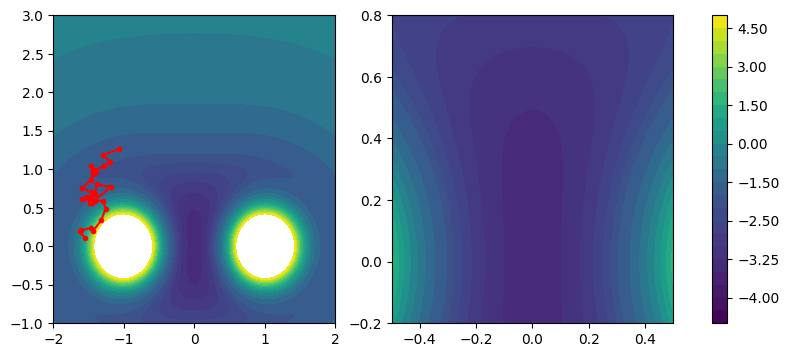

In [14]:
cluster = AtomicClusterWithRattleOfFirstAtom(morse, pos=np.array([[-1,1.2],[-1,0],[1,0]]),  static = [True, False, False])

def monte_carlo_quench(cluster, Nsteps):
    visited_positions = []
    test = cluster.copy()
    for _ in range(Nsteps):
        test.rattle_first_atom()
        delta_e = test.potential_energy - cluster.potential_energy
        #print(test.potential_energy, cluster)
        # in the limit T -> 0, all steps that increase energy are rejected
        visited_positions.append(test.get_positions()[0])
        if delta_e < 0:
            # let cluster get the positions of test
            cluster.set_positions(test.get_positions())
    return visited_positions

visited = monte_carlo_quench(cluster=cluster, Nsteps=30)
print(len(visited))
xpos, ypos = zip(*visited)

fig, axes = plt.subplots(1,2,figsize=(10,4))
for ax in axes:
    ax.plot(xpos,ypos,'.-', color='red')
    cf = ax.contourf(xd, yd, zd, levels=levels)

axes[1].set_ylim(-0.2,0.8)
axes[1].set_xlim(-0.5,0.5)

fig.colorbar(cf, ax=axes)

Here I show what that would look like. The returned positions are not the actual cluster moving, because probably not that many would be accepted. This is the path of test.

# W03C - Monte Carlo Optimization, Many-D example

In [15]:
from week03 import nice_plot
from week03 import Morse
from week03 import AtomicClusterBase2
import numpy as np
import matplotlib.pyplot as plt

In [16]:
calc = Morse()
class AtomicCluster(AtomicClusterBase2):
    pass
cluster = AtomicCluster(calc, pos=[[-0.5,0],[0, np.sqrt(3)/2],[0.5,0]],static=[True, False, True])
print(cluster.potential_energy)

-4.5


In [17]:
class AtomicCluster(AtomicClusterBase2):
    def rattle_random_dynamic_atom(self, A=0.01):
        index = np.random.choice(self.indices_dynamic_atoms)
        self.pos[index][0] += np.random.normal(0, A) #add a normally distributed random vector to the position of the selected atom
        self.pos[index][1] += np.random.normal(0, A)

def monte_carlo_quench (cluster , N):
    test = cluster.copy ()
    for _ in range(N):
        test.set_positions(cluster.get_positions())
        test.rattle_random_dynamic_atom(A=0.1)
        de = test.potential_energy - cluster.potential_energy # evaluating the energy difference
        if de < 0: # monte carlo quench when T=0
            cluster.set_positions(test.get_positions())

In this code, test=cluster.copy() can appear outside the for loop, since the test positions are updated every iteration to mimic the cluster. Comparing to the previous code, we made a copy every iteration. Now we make one copy, but update its position every iteration to mimic the cluster.

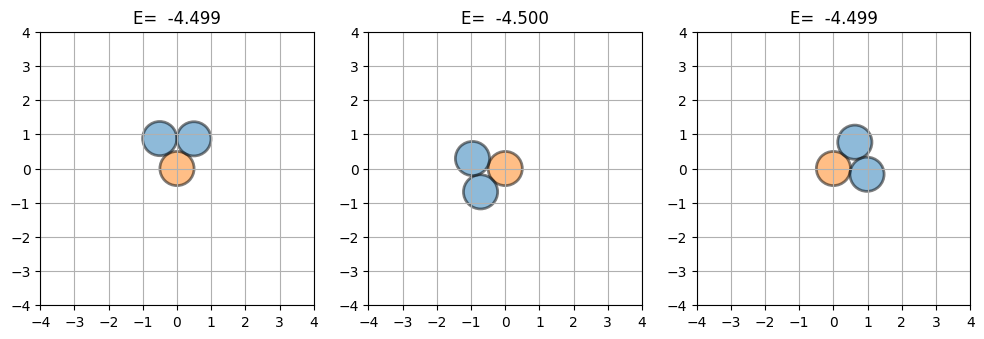

In [18]:
fig, axes = plt.subplots(1,3,figsize=(12,4))
for ax in axes:
    N = 3
    cluster = AtomicCluster (calc , N=N, static =[ True] + [False] * (N -1))
    cluster.pos[0] = [0,0] #overwriting the x,y- positions for the first atom.
    monte_carlo_quench(cluster, 1000)
    nice_plot(ax, [ -4 ,4], [ -4 ,4])
    cluster.draw(ax)

Now modified morse potential, where we disfavor configurations where any three atoms for equilateral triangles.

10.30021242968685


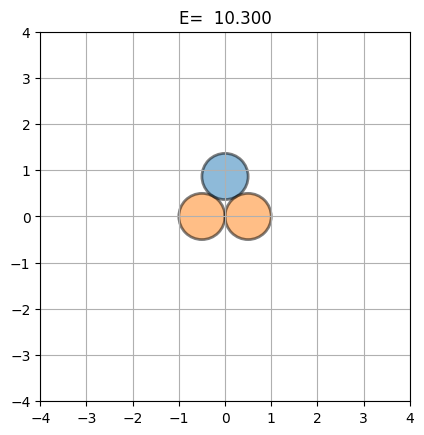

In [19]:
from week03 import ModifiedMorse

calc = ModifiedMorse()
cluster = AtomicCluster(calc, pos=[[-0.5,0],[0, np.sqrt(3)/2],[0.5,0]],static=[True, False, True])
print(cluster.potential_energy)
fig, ax = plt.subplots()
nice_plot(ax, [ -4 ,4], [ -4 ,4])
cluster.draw(ax)

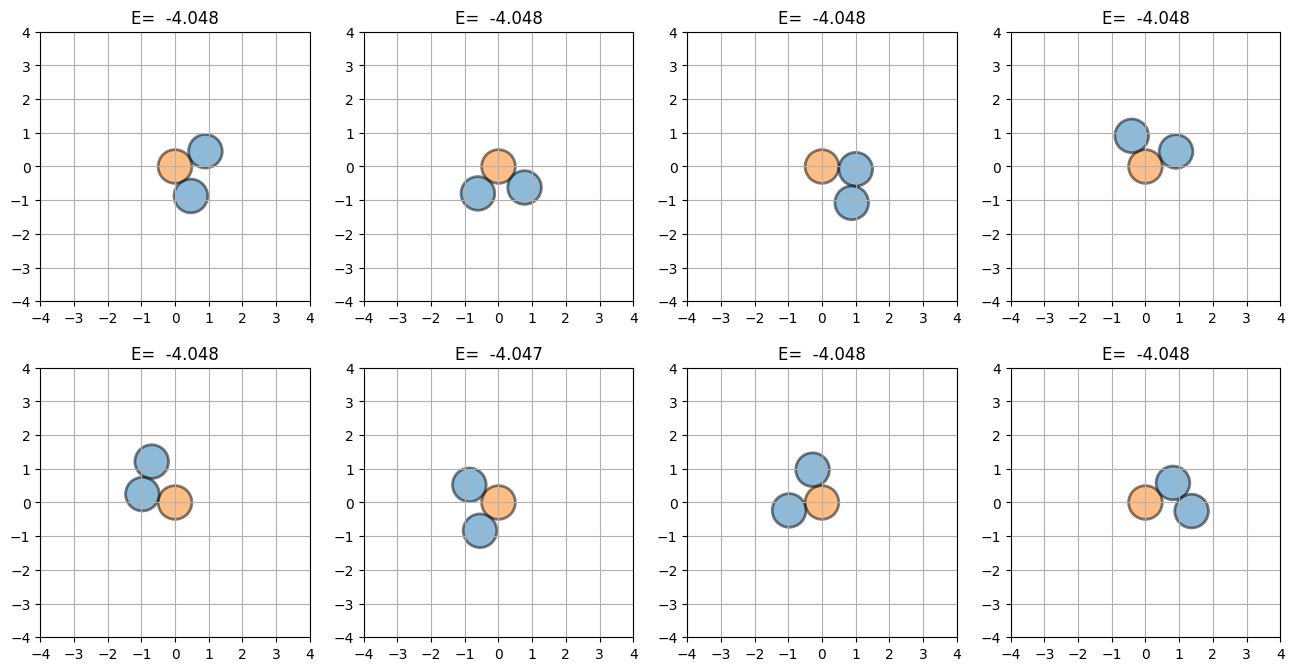

In [20]:
fig, axes = plt.subplots(2,4,figsize=(16,8))
for ax in axes.flatten():
    N = 3
    cluster = AtomicCluster (calc , N=N, static =[ True] + [False] * (N -1))
    cluster.pos[0] = [0,0] #overwriting the x,y- positions for the first atom.
    monte_carlo_quench(cluster, 1000)
    nice_plot(ax, [ -4 ,4], [ -4 ,4])
    cluster.draw(ax)

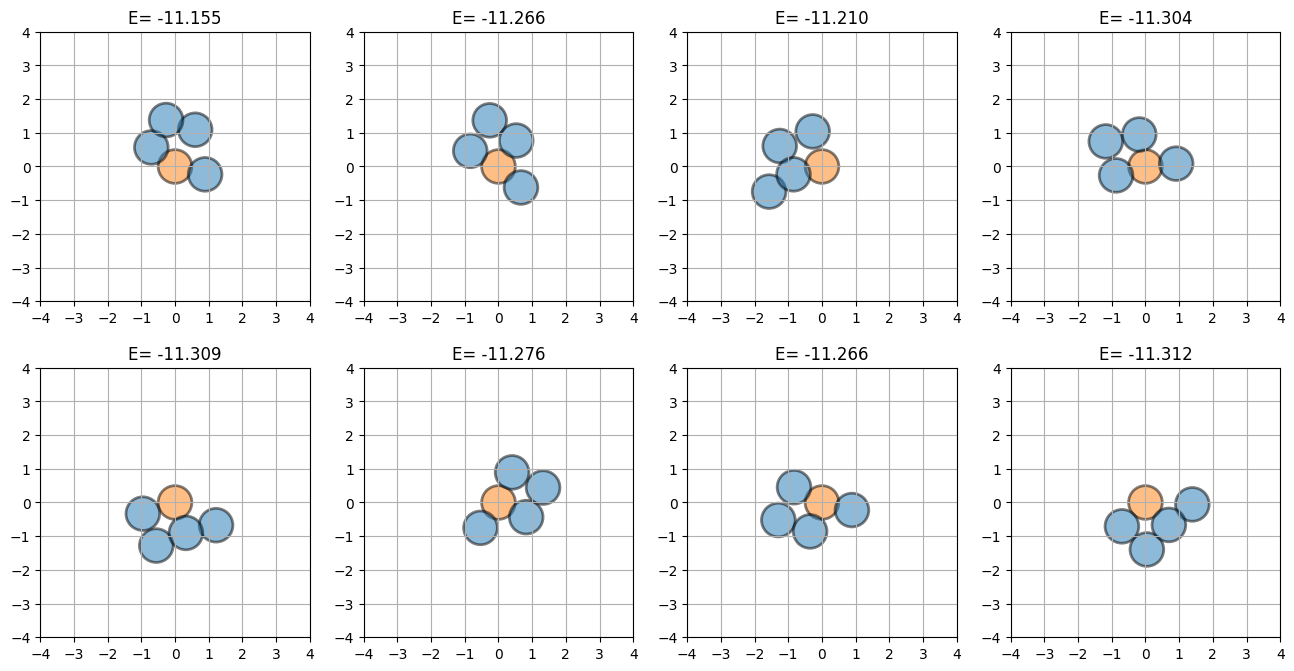

In [21]:
fig, axes = plt.subplots(2,4,figsize=(16,8))
for ax in axes.flatten():
    N = 5
    cluster = AtomicCluster (calc , N=N, static =[ True] + [False] * (N -1))
    cluster.pos[0] = [0,0] #overwriting the x,y- positions for the first atom.
    monte_carlo_quench(cluster, 1000)
    nice_plot(ax, [ -4 ,4], [ -4 ,4])
    cluster.draw(ax)

# W03D - Gradient-based optimization: Finite-difference force

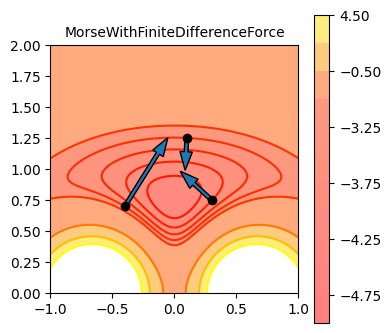

In [22]:
from week03 import Morse
class  MorseWithFiniteDifferenceForce (Morse):
    def forces(self, pos, delta=1e-6):
        N, dim = pos.shape
        forces = np.zeros(pos.shape)
        for i in range(N):
            for d in range(dim):
                # Positive displacement
                pos_forward = np.array(pos, copy=True)
                pos_forward[i, d] += delta
                e_forward = self.potential_energy(pos_forward)
                # Negative displacement
                pos_backward = np.array(pos , copy=True)
                pos_backward[i, d] -= delta
                e_backward = self. potential_energy(pos_backward)
                # Central difference
                forces[i, d] = -( e_forward - e_backward ) / (2*delta)
        return forces

calc = MorseWithFiniteDifferenceForce()

from week03 import base_plot
pos0 = [[-.8 ,.6], [-0.65 , 0], [0.65 , 0]]
fig, ax = base_plot(pos0 , calc)

from week03 import AtomicClusterBase2 as AtomicCluster
p0s = [[0.1, 1.25], [0.3, 0.75], [-0.4, 0.7]]
for p0 in p0s:
    ax.plot(*p0, 'ko', zorder=20)
    pos = [p0, [-0.65 , 0], [0.65 , 0]]
    cluster = AtomicCluster(calc, pos=pos, static = [False , True , True])
    scale = 0.1
    f = cluster.forces[0 ,:] * scale
    ax.arrow(*p0 , *f, width=.03, head_width=.1, length_includes_head =True, facecolor='C0', zorder=10)


Now we try it out again, but with the ModifiedMorse Calculator, which disfavor configurations where any three atoms for equilateral triangles.
We have to write all the code again. The smartest way would be to implement the method 'def forces' in the calculator class, but since we pick the calculator from a library, that is not good programming style to do.

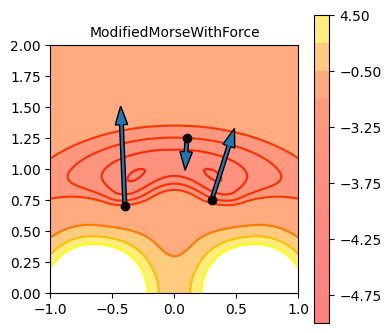

In [23]:
from week03 import ModifiedMorse
class ModifiedMorseWithForce(ModifiedMorse):
    def forces(self, pos, delta=1e-6):
        N, dim = pos.shape
        forces = np.zeros(pos.shape)
        for i in range(N):
            for d in range(dim):
                # Positive displacement
                pos_forward = np.array(pos, copy=True)
                pos_forward[i, d] += delta
                e_forward = self.potential_energy(pos_forward)
                # Negative displacement
                pos_backward = np.array(pos , copy=True)
                pos_backward[i, d] -= delta
                e_backward = self. potential_energy(pos_backward)
                # Central difference
                forces[i, d] = -( e_forward - e_backward ) / (2*delta)
        return forces

calc = ModifiedMorseWithForce()

pos0 = [[-.8 ,.6], [-0.65 , 0], [0.65 , 0]]
fig, ax = base_plot(pos0 , calc)

p0s = [[0.1, 1.25], [0.3, 0.75], [-0.4, 0.7]]
for p0 in p0s:
    ax.plot(*p0, 'ko', zorder=20)
    pos = [p0, [-0.65 , 0], [0.65 , 0]]
    cluster = AtomicCluster(calc, pos=pos, static = [False , True , True])
    scale = 0.1
    f = cluster.forces[0 ,:] * scale
    ax.arrow(*p0 , *f, width=.03, head_width=.1, length_includes_head =True, facecolor='C0', zorder=10)

We see how the potential landscape changed since we disfavor equilateral triangles.

### Steepest descent

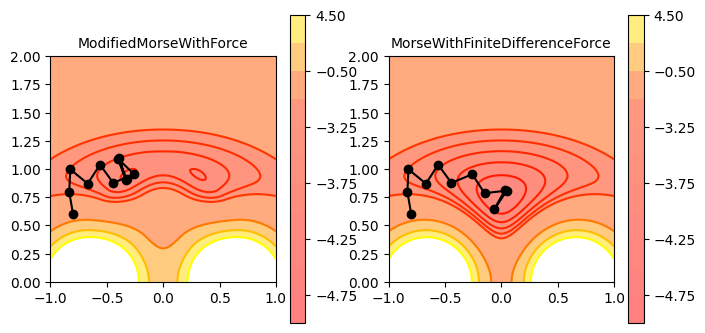

In [24]:
def steepest_descent(cluster, Nsteps=1, step_length=0.2):
    for _ in range(Nsteps):
        pos = cluster.get_positions()
        forces = cluster.forces
        direction = forces / np.linalg.norm(forces)
        pos += step_length * direction
        cluster.set_positions(pos)


calc = ModifiedMorseWithForce()
mod_calc = MorseWithFiniteDifferenceForce()

pos0 = [[-.8 ,.6], [-0.65 , 0], [0.65 , 0]]
fig, axes = base_plot(pos0 , [calc,mod_calc])

p0 = [-0.8,0.6]
pos = [p0, [-0.65 , 0], [0.65 , 0]]
for i, calcualtor in enumerate([calc, mod_calc]):
    cluster = AtomicCluster(calcualtor, pos=pos, static = [False , True , True])
    positions = [p0]
    for _ in range(10):  # 10 steps
        steepest_descent(cluster)
        positions.append(cluster.pos[0])
    x,y = zip(*positions)
    axes[i].plot(x,y,'ko-',zorder=20)

Notice how the atom jumps back and forward at the minimum because of the fixed step size. To alter the step size as we get toward the minimum, we introduce gradient descent, i.e. the gradient determines how big the step should be (with a factor). If the force is very large, the step will be big because the gradient is large.

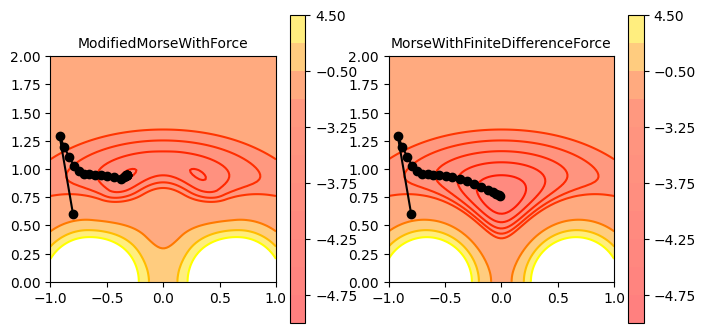

In [25]:
def gradient_descent(cluster ,Nsteps =1, gamma=0.05):
    for _ in range(Nsteps):
        pos = cluster.get_positions()
        forces = cluster.forces
        pos += gamma*forces
        cluster.set_positions(pos)

calc = ModifiedMorseWithForce()
mod_calc = MorseWithFiniteDifferenceForce()

pos0 = [[-.8 ,.6], [-0.65 , 0], [0.65 , 0]]
fig, axes = base_plot(pos0 , [calc,mod_calc])

p0 = [-0.8,0.6]
pos = [p0, [-0.65 , 0], [0.65 , 0]]
for i, calcualtor in enumerate([calc, mod_calc]):
    cluster = AtomicCluster(calcualtor, pos=pos, static = [False , True , True])
    positions = [p0]
    for _ in range(20):  # 20 steps
        gradient_descent(cluster)
        positions.append(cluster.pos[0])
    x,y = zip(*positions)
    axes[i].plot(x,y,'ko-',zorder=20)

An issue may be that very large steps are taken when the force is high, and we may overshoot the minimum, doing uneccesary many steps. A maximum step can be introduced.

Both steepest_gradient and gradient_descent are often reffered to as 'gradient descent', however one is a fixed step size along the gradient, the other is a step based on the gradient.

It may be difficult to choose a suitable step size. Instead, **line search** can be utilized to turn the multidimensional optimization problem into a one-dimensional problem.

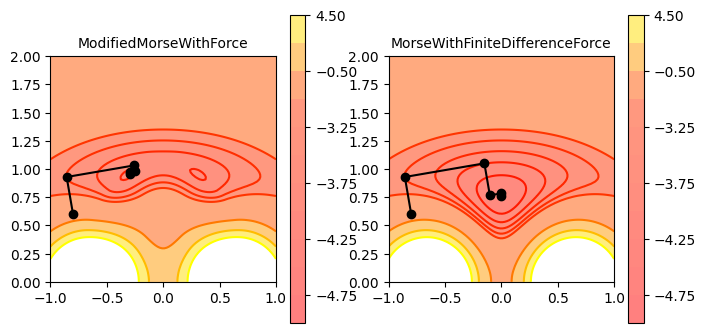

In [26]:
from scipy.optimize import fmin
def line_search (cluster, steps=100, fnorm_min=1e-5, xtol=1e-8, ftol=1e-8):
    test = cluster.copy()

    def potential_energy_of_alpha(alpha, p):
        test.set_positions(cluster.get_positions() + alpha * p)
        return test.potential_energy

    for i in range(steps):
        f = cluster.forces
        fnorm = np.linalg.norm(f)
        if fnorm < fnorm_min :
            return
        p = f / fnorm
        alpha_opt = fmin(lambda alpha: potential_energy_of_alpha(alpha, p), 0.1, disp=False , xtol=xtol , ftol=ftol)
        cluster.set_positions(cluster.get_positions() + alpha_opt * p)

calc = ModifiedMorseWithForce()
mod_calc = MorseWithFiniteDifferenceForce()

pos0 = [[-.8 ,.6], [-0.65 , 0], [0.65 , 0]]
fig, axes = base_plot(pos0 , [calc,mod_calc])

p0 = [-0.8,0.6]
pos = [p0, [-0.65 , 0], [0.65 , 0]]
for i, calcualtor in enumerate([calc, mod_calc]):
    cluster = AtomicCluster(calcualtor, pos=pos, static = [False , True , True])
    positions = [p0]
    for _ in range(5):  # 5 steps
        line_search(cluster, steps=1)
        positions.append(cluster.pos[0])
    x,y = zip(*positions)
    axes[i].plot(x,y,'ko-',zorder=20)

# W03E - Analytic Force for Morse Potential

$V(r)=\varepsilon\left[\left(1-e^{-a(r-r_0)}\right)^2-1\right]$

$\frac{d}{dr} V(r)$

2*a*eps*(1 - exp(-a*(r - r0)))*exp(-a*(r - r0))

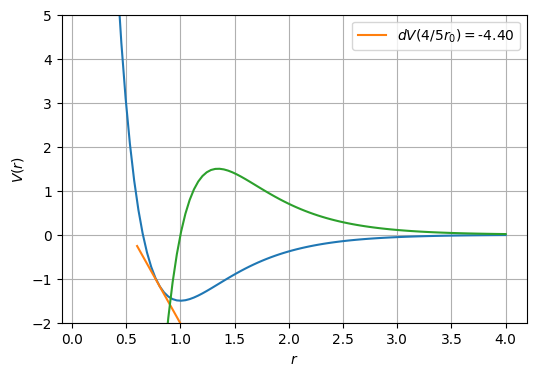

In [27]:
import sympy as sp

r, eps, a, r0 = sp.symbols('r eps a r0')
V = eps*((1-sp.exp(-a*(r-r0)))**2 - 1)
dV = sp.diff(V, r)
display(dV)

V_lambda = sp.lambdify((r, eps, a, r0), V, 'numpy')
dV_lambda = sp.lambdify((r, eps, a, r0), dV, 'numpy')

rspace = np.linspace(0.1, 4, 100)
eps = 3/2
a = 2
r0 = 1
V_pot = V_lambda(rspace, eps, a, r0)
dV_pot = dV_lambda(rspace, eps, a, r0)

r_test_space = np.linspace(0.6, 1, 10)
r_test = 4/5*r0
V_test = V_lambda(r_test, eps, a, r0)
dV_test = dV_lambda(r_test, eps, a, r0)
V_tangent = V_test + dV_test * (r_test_space-r_test)

fig, ax = plt.subplots(1,1,figsize=(6,4))
ax.plot(rspace, V_pot)
ax.plot(r_test_space, V_tangent, label=r'$dV(4/5r_0)=$' + f'{dV_lambda(r_test, eps, a, r0):.2f}')
ax.plot(rspace, dV_pot)
ax.legend()
ax.set_ylim(-2,5)
ax.set_xlabel(r'$r$')
ax.set_ylabel(r'$V(r)$')
ax.grid(True)


-0.900635398659408
[[ 1.39526495  0.        ]
 [-1.39526495  0.        ]]


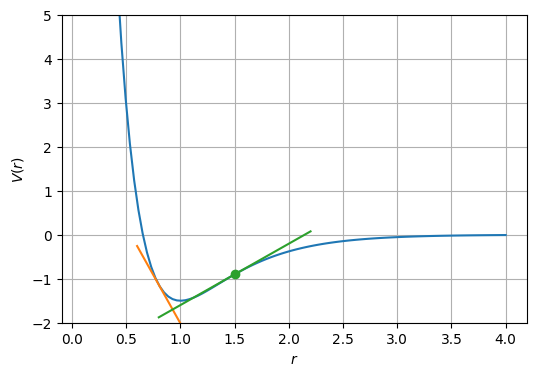

In [28]:
class Calculator():
    def potential_energy(self, pos):
        return np.sum(self._V(pdist(pos)))
    def forces(self, pos):
        diff = pos[:, np.newaxis, :] - pos[np.newaxis, :, :]
        r = np.sqrt(np.sum(diff**2, axis=-1))
        np.fill_diagonal(r, np.inf)
        force_magnitude = -self._dV_dr(r)
        forces = np.sum(force_magnitude[..., np.newaxis] * diff / \
        r[..., np.newaxis], axis =1)
        return forces

class Morse(Calculator):
    def _V(self, r, eps=3/2, a=2, r0=1):
        return eps*((1-np.exp(-a*(r-r0)))**2 - 1)
    
    def _dV_dr(self, r, eps=3/2, a=2, r0=1):
        return 2*a*eps*(1-np.exp(-a*(r-r0)))*np.exp(-a*(r-r0))


pos = np.array([[0 , 0], [3/2 , 0]])

morse = Morse()
potential = morse.potential_energy(pos)
forces = morse.forces(pos)
print(potential)
print(forces)

r_atom_space = np.linspace(0.8, 2.2, 10)  # make the tangent the size of the forces
r_atom = 3/2
V_atom = V_lambda(r_atom, eps, a, r0)
dV_atom = dV_lambda(r_atom, eps, a, r0)
V_tangent_atom = V_atom + dV_atom * (r_atom_space-r_atom)

fig, ax = plt.subplots(1,1,figsize=(6,4))
ax.plot(rspace, V_pot)
ax.plot(r_test_space, V_tangent)
ax.plot(r_atom_space, V_tangent_atom)
ax.plot(r_atom, V_atom, 'C2o')
# ax.legend()
ax.set_ylim(-2,5)
ax.set_xlabel(r'$r$')
ax.set_ylabel(r'$V(r)$')
ax.grid(True)


Remember that the gradiant of the energy is the negative force, i.e. $\frac{dV}{dr}=-F(r)$

The energy at point $r$ can be approximated (taylor) like:

$E(r) \simeq E(r_0)+\frac{dE}{dr}|_{r_0}(r-r_0) = E(r_0) - F(r_0) \cdot (r-r_0)$

This is what I use to determine the gradiant and plot the tangent. 

In the figure, the force can be seen as the gradient $\sim 1.4$

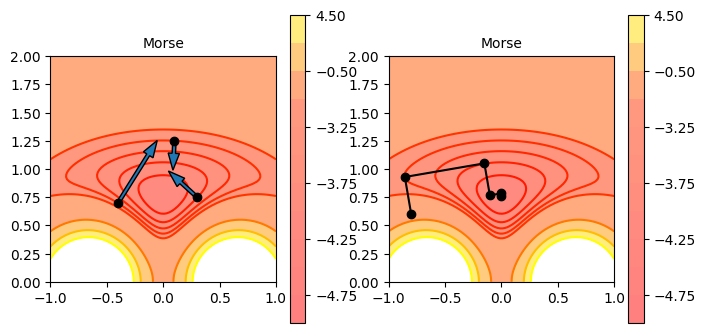

In [29]:
calc = Morse()

pos0 = [[-.8 ,.6], [-0.65 , 0], [0.65 , 0]]
fig, axes = base_plot(pos0 , [calc, calc])

# plot arrows
p0s = [[0.1, 1.25], [0.3, 0.75], [-0.4, 0.7]]
for p0 in p0s:
    axes[0].plot(*p0, 'ko', zorder=20)
    pos = [p0, [-0.65 , 0], [0.65 , 0]]
    cluster = AtomicCluster(calc, pos=pos, static = [False , True , True])
    scale = 0.1
    f = cluster.forces[0 ,:] * scale
    axes[0].arrow(*p0 , *f, width=.03, head_width=.1, length_includes_head =True, facecolor='C0', zorder=10)

# plot line search
p0 = [-0.8,0.6]
pos = [p0, [-0.65 , 0], [0.65 , 0]]
cluster = AtomicCluster(calc, pos=pos, static = [False , True , True])
positions = [p0]
for _ in range(5):  # 5 steps
    line_search(cluster, steps=1)
    positions.append(cluster.pos[0])
x,y = zip(*positions)
axes[1].plot(x,y,'ko-',zorder=20)

Using the new calculator that uses analytical solutions for obtaining potential energy and forces, we get the exact same plots as before.

# W03F - Basin Hopping

Acceptance ratio: 0.6
Acceptance ratio: 0.55
Acceptance ratio: 0.6
Acceptance ratio: 0.5
Acceptance ratio: 0.45
Acceptance ratio: 0.65
Acceptance ratio: 0.65
Acceptance ratio: 0.55
Acceptance ratio: 0.6
Acceptance ratio: 0.65
Acceptance ratio: 0.4
Acceptance ratio: 0.55
Acceptance ratio: 0.55
Acceptance ratio: 0.65
Acceptance ratio: 0.5


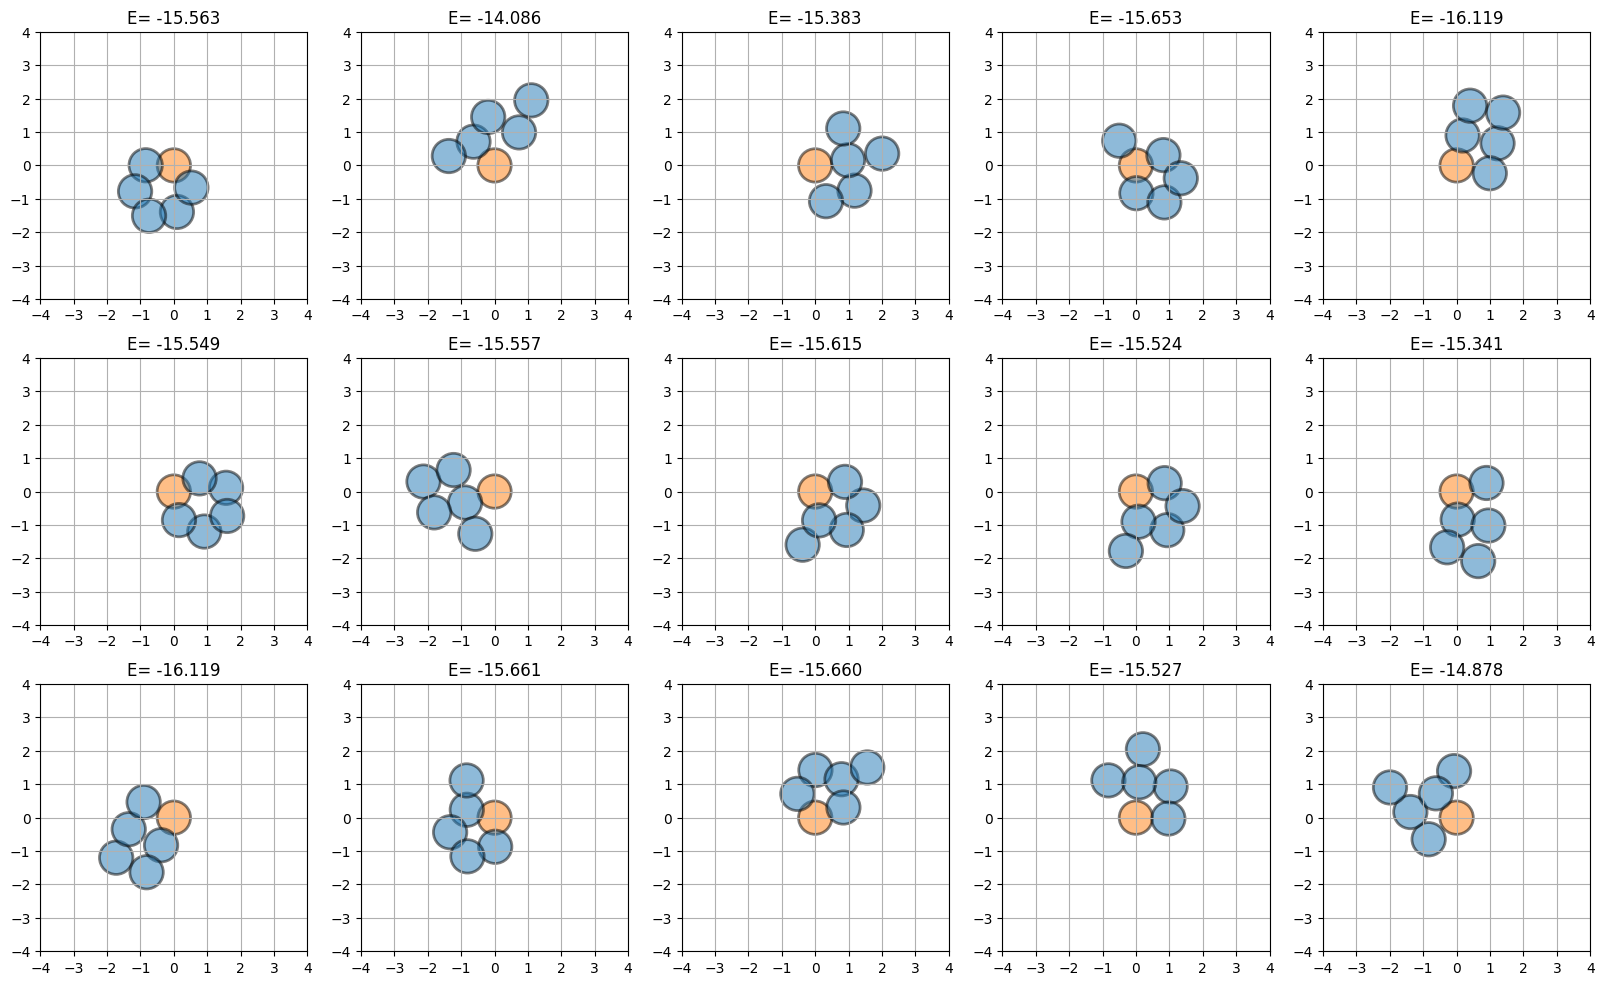

In [30]:
import numpy as np
import matplotlib.pyplot as plt

from week03 import AtomicClusterBase2, ModifiedMorse, nice_plot

class AtomicCluster(AtomicClusterBase2):
    def rattle_random_dynamic_atom(self, A=0.01):
        index = np.random.choice(self.indices_dynamic_atoms)
        self.pos[index][0] += np.random.normal(0, A) #add a normally distributed random vector to the position of the selected atom
        self.pos[index][1] += np.random.normal(0, A)


from scipy.optimize import fmin
def line_search (cluster, steps=100, fnorm_min=1e-5, xtol=1e-8, ftol=1e-8):
    test = cluster.copy()

    def potential_energy_of_alpha(alpha, p):
        test.set_positions(cluster.get_positions() + alpha * p)
        return test.potential_energy

    for i in range(steps):
        f = cluster.forces
        fnorm = np.linalg.norm(f)
        if fnorm < fnorm_min :
            return
        p = f / fnorm
        alpha_opt = fmin(lambda alpha: potential_energy_of_alpha(alpha, p), 0.1, disp=False , xtol=xtol , ftol=ftol)
        cluster.set_positions(cluster.get_positions() + alpha_opt * p)


def basin_hopping(cluster, Nsteps=10, kT=0.5, Nrattle=5, Arattle=0.1):
    test = cluster.copy()
    Naccept = 0
    for _ in range(Nsteps):
        test.set_positions(cluster.get_positions())
        for _ in range(Nrattle):
            test.rattle_random_dynamic_atom(A=Arattle)
        line_search(test)
        de = test.potential_energy - cluster.potential_energy
        if np.random.rand() < np.exp(-de/kT):
            cluster.set_positions(test.get_positions())
            Naccept += 1
    print('Acceptance ratio:', Naccept / Nsteps)

def simulate(filename, Nsteps=10, kT=0.5, Nrattle=5, Arattle=0.1):
    calc = ModifiedMorseWithForce()  # disfavor equilateral triangles
    fig, axes = plt.subplots(3,5,figsize=(20,12))
    for ax in axes.flatten():
        N = 6
        cluster = AtomicCluster(calc , N=N, static = [True] + [False] * (N-1))
        cluster.pos[0] = [0,0] #overwriting the x,y- positions for the first atom.
        basin_hopping(cluster, Nsteps, kT, Nrattle, Arattle)
        nice_plot(ax, [-4 ,4], [-4 ,4])
        cluster.draw(ax)
    fig.savefig(filename)


simulate('testing.pdf', Nsteps=20, kT=1, Nrattle=10, Arattle=0.5)
# simulate('filename1.pdf', Nsteps =25, kT=2, Nrattle =10, Arattle =0.5)
# simulate('filename2.pdf', Nsteps =25, kT=.2, Nrattle =10, Arattle =0.5)
# simulate('filename3.pdf', Nsteps =25, kT=.2, Nrattle =10, Arattle =0.05)